# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Pangestuti Bunga Yuliyanti
- **Email:** 	CDCC626D6X0159@student.devacademy.id
- **ID Dicoding:** CDCC626D6X0159

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Kategori produk manakah yang memiliki total revenue tertinggi tetapi memiliki rata-rata skor review di bawah 4 selama periode Januari - Desember 2018?
- **Pertanyaan 2:** Berapa jumlah pelanggan yang termasuk dalam kategori “churn risk” berdasarkan lamanya waktu sejak transaksi terakhir melebihi 90 hari dan intensitas pembelian yang kurang dari 2 transaksi selama periode Januari – Desember 2018?

## Import Packages/Library yang Digunakan

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Wrangling

### Gathering Data

Dataset yang digunakan, yaitu:

- **customers**: berisi informasi pelanggan.
- **orders**: berisi informasi transaksi.
- **order_items**: berisi detail produk dalam setiap transaksi termasuk harga dan biaya pengiriman.
- **order_reviews**: berisi penilaian pelanggan terhadap pesanan dalam bentuk skor.
- **products**: berisi informasi terkait produk.
- **product_category_name_translation**: berisi terjemahan kategori produk dari bahasa Portugis ke bahasa Inggris.

#### Load df customers, orders, items, reviews, products, and category_translation

In [ ]:
customers_df = pd.read_csv('/content/drive/My Drive/E-Commerce Public Dataset/customers_dataset.csv')
orders_df = pd.read_csv('/content/drive/My Drive/E-Commerce Public Dataset/orders_dataset.csv')
order_items_df = pd.read_csv('/content/drive/My Drive/E-Commerce Public Dataset/order_items_dataset.csv')
order_reviews_df = pd.read_csv('/content/drive/My Drive/E-Commerce Public Dataset/order_reviews_dataset.csv')
products_df = pd.read_csv('/content/drive/My Drive/E-Commerce Public Dataset/products_dataset.csv')
products_translation_df = pd.read_csv('/content/drive/My Drive/E-Commerce Public Dataset/product_category_name_translation.csv')

datasets = {
    'customers': customers_df,
    'orders':    orders_df,
    'items':     order_items_df,
    'reviews':   order_reviews_df,
    'products':  products_df,
    'category_translation': products_translation_df
}

for name, df in datasets.items():
  print(f'{name}, shape={df.shape}')
  display(df.head())

customers, shape=(99441, 5)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


orders, shape=(99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


items, shape=(112650, 7)


...

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


products, shape=(32951, 9)


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


category_translation, shape=(71, 2)


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


**Insight:**
- Dataset customer memiliki sejumlah 99441 data dengan 5 kolom
- Dataset orders memiliki sejumlah 99441 data dengan 8 kolom
- Dataset items memiliki sejumlah 112650 data dengan 7 kolom
- Dataset reviews memiliki sejumlah 99224 data dengan 7 kolom
- Dataset products memiliki sejumlah 32951 data dengan 9 kolom
- Dataset category_translation memiliki sejumlah 71 data dengan 2 kolom

### Assessing Data

#### Identifying data type problem

In [ ]:
datetime_columns = [
  "order_purchase_timestamp", "order_approved_at",
  "order_delivered_carrier_date", "order_delivered_customer_date",
  "order_estimated_delivery_date"
]

print("Tipe data kolom tanggal:")
for col in datetime_columns:
  print(f"  {col:<40} {orders_df[col].dtype}")

Tipe data kolom tanggal:
  order_purchase_timestamp                 object
  order_approved_at                        object
  order_delivered_carrier_date             object
  order_delivered_customer_date            object
  order_estimated_delivery_date            object


**Steps to Take:**
- Mengubah tipe data pada kolom tanggal tersebut menjadi datetime.

#### Identifying missing value problem

In [ ]:
for name, df in datasets.items():
  missing = df.isnull().sum()
  missing = missing[missing > 0]
  if len(missing) > 0:
    print(f'\n{name}' )
    for col, val in missing.items():
      print(f'{col}: {val}')
  else:
    print(f'\n{name}: No missing values')


customers: No missing values

orders
order_approved_at: 160
order_delivered_carrier_date: 1783
order_delivered_customer_date: 2965

items: No missing values

reviews
review_comment_title: 87656
review_comment_message: 58247

products
product_category_name: 610
product_name_lenght: 610
product_description_lenght: 610
product_photos_qty: 610
product_weight_g: 2
product_length_cm: 2
product_height_cm: 2
product_width_cm: 2

category_translation: No missing values


**Steps to Take:**
- Tidak ada permasalahan pada dataset `customers`, `items`, dan `category_translation`. Sudah siap digunakan dalam analisis.
- Pada dataset `orders` kolom pengiriman akan diselesaikan dalam tahap EDA.
- Pada dataset `reviews` kolom comment tidak digunakan dalam analisis, maka akan dibiarkan.
- Pada dataset `products` akan dilakukan penambahan nama kategori "unknown" bagi produk yang tidak memiliki nama kategori pada kolom `product_category_name`. Kolom lainnya pada dataset tersebut tidak akan digunakan karena tidak dibutuhkan dalam analisis.

#### Identifying duplicate data problem

In [ ]:
for name, df in datasets.items():
  duplicate = df.duplicated().sum()
  duplicate = duplicate[duplicate > 0]
  if len(duplicate) > 0:
    print(f'{name}' )
    for col, val in duplicate.items():
      print(f'{col}: {val}')
  else:
    print(f'{name}: No duplicate data')

# Periksa jumlah duplikat pada id
print(f'\nJumlah duplikat pada customer_id:', customers_df['customer_id'].duplicated().sum())
print(f'Jumlah duplikat pada order_id:', orders_df['order_id'].duplicated().sum())
print(f'Jumlah duplikat pada review_id:', order_reviews_df['review_id'].duplicated().sum())
print(f'Jumlah duplikat pada product_id:', products_df['product_id'].duplicated().sum())

customers: No duplicate data
orders: No duplicate data
items: No duplicate data
reviews: No duplicate data
products: No duplicate data
category_translation: No duplicate data

Jumlah duplikat pada customer_id: 0
Jumlah duplikat pada order_id: 0
Jumlah duplikat pada review_id: 814
Jumlah duplikat pada product_id: 0


**Steps to Take:**
- Terdapat duplikat data pada `review_id` pada dataset `order_reviews_df`. Hal ini akan berpengaruh pada akumulasi skor review karena terdapat beberapa review dalam satu kali order, sehingga hanya perlu diambil review yang terakhir kali dan review sisanya dihapus.

#### Identifying invalid value problem

In [ ]:
# Cek apakah tanggal pengiriman kosong dan perbandingan antara tanggal pengiriman dengan tanggal purchase
invalid_dates = orders_df[
    orders_df['order_delivered_customer_date'].notna() &
    (orders_df['order_delivered_customer_date'] < orders_df['order_purchase_timestamp'])
]
print(f'Jumlah delivered_date < purchase_date: {len(invalid_dates)}')

Jumlah delivered_date < purchase_date: 0


In [ ]:
# Cek item yang memiliki nilai negatif pada price atau freight
neg_price   = (order_items_df['price'] <= 0).sum()
neg_freight = (order_items_df['freight_value'] < 0).sum()
print(f'Items dengan price <= 0: {neg_price}')
print(f'Items dengan freight_value < 0: {neg_freight}')

Items dengan price <= 0: 0
Items dengan freight_value < 0: 0


In [ ]:
# Cek score berada di bukan rentang 1-5
invalid_score = order_reviews_df[
                  (order_reviews_df['review_score'] > 5) |
                  (order_reviews_df['review_score'] < 1)
                ]
print(f'Jumlah invalid_score: {len(invalid_score)}')

Jumlah invalid_score: 0


In [ ]:
# Cek status distribusi pesanan
print('Status distribusi pesanan:')
print(orders_df['order_status'].value_counts())

Status distribusi pesanan:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


**Steps to Take:**
- Data sudah siap masuk ke tahap cleaning karena tidak ada permasalahan invalid value


#### Identifying outlier problem

In [ ]:
order_items_df.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


**Steps to Take:**
- Perlu memvalidasi nilai maksimum pada kolom `price` dan `freight_value` karena terlihat perbedaan yang sangat jauh dengan nilai kuartil atas (Q3). Hal ini mengindikasikan adanya outlier dan mempengaruhi hasil analisis.


### Cleaning Data

#### Fixing data type problem on orders df

In [ ]:
datetime_columns = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date", "order_estimated_delivery_date"]

for column in datetime_columns:
  orders_df[column] = pd.to_datetime(orders_df[column])

print(orders_df[datetime_columns].dtypes)

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


#### Fixing missing values problem

In [ ]:
products_df['product_category_name'] = products_df['product_category_name'].fillna('unknown')
print('Missing category setelah perbaikan :', products_df['product_category_name'].isnull().sum())

Missing category setelah perbaikan : 0


#### Fixing duplicate data problem

In [ ]:
before = len(order_reviews_df)
df_reviews_clean = order_reviews_df.sort_values('review_answer_timestamp') \
                                    .drop_duplicates(subset='order_id', keep='last') \
                                    .reset_index(drop=True)
after = len(df_reviews_clean)
print(f'Reviews sebelum: {before:} \nSetelah perbaikan: {after:} \nJumlah dihapus: {before-after:}')

Reviews sebelum: 99224 
Setelah perbaikan: 98673 
Jumlah dihapus: 551


#### Fixing outlier problem on order item df

In [ ]:
for col in ['price', 'freight_value']:
  Q1  = order_items_df[col].quantile(0.25)
  Q3  = order_items_df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  order_items_df[col] = order_items_df[col].clip(
    lower=max(lower, 0), upper=upper
  )

print(order_items_df[['price', 'freight_value']].describe())

               price  freight_value
count  112650.000000  112650.000000
mean       98.444222      17.821461
std        75.923244       7.424145
min         0.850000       0.975000
25%        39.900000      13.080000
50%        74.990000      16.260000
75%       134.900000      21.150000
max       277.400000      33.255000


#### Build master DataFrame

In [ ]:
# Memfilter order dengan status "deivered" pada tahun 2018
orders_df_2018 = orders_df[
    (orders_df['order_status'] == 'delivered') &
    (orders_df['order_purchase_timestamp'].dt.year == 2018)
].copy()

print(f'Orders 2018 (delivered): {len(orders_df_2018):,}')
print(f'Date range: {orders_df_2018["order_purchase_timestamp"].min().date()} to '
      f'{orders_df_2018["order_purchase_timestamp"].max().date()}')

Orders 2018 (delivered): 52,783
Date range: 2018-01-01 to 2018-08-29


In [ ]:
# Buat master dataframe
master_df = (
    orders_df_2018
    .merge(order_items_df, on='order_id', how='left')
    .merge(products_df[['product_id', 'product_category_name']], on='product_id', how='left')
    .merge(products_translation_df, on='product_category_name', how='left')
    .merge(df_reviews_clean[['order_id', 'review_score']], on='order_id', how='left')
    .merge(customers_df[['customer_id', 'customer_unique_id',
                          'customer_city', 'customer_state']], on='customer_id', how='left')
)

# Menghitung revenue per item (price + freight)
master_df['revenue'] = master_df['price'] + master_df['freight_value']

# Mengisi kategori terjemahan yang hilang
master_df['product_category_name_english'] = (
    master_df['product_category_name_english']
    .fillna(master_df['product_category_name'])
)

print(f'Master DataFrame shape: {master_df.shape}')
master_df.head(3)

Master DataFrame shape: (60324, 21)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english,review_score,customer_unique_id,customer_city,customer_state,revenue
0,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,2018-07-30 03:24:27,118.7,22.76,perfumaria,perfumery,4.0,af07308b275d755c9edb36a90c618231,barreiras,BA,141.46
1,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,2018-08-13 08:55:23,159.9,19.22,automotivo,auto,5.0,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,179.12
2,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,...,2018-02-19 20:31:37,19.9,8.72,papelaria,stationery,5.0,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,28.62


## Exploratory Data Analysis (EDA)

### Explore Data for Business Question 1

In [ ]:
# Agregasi per kategori
category_df = (
    master_df.groupby('product_category_name_english', as_index=False)
    .agg(
        total_revenue=('revenue', 'sum'),
        avg_review_score=('review_score', 'mean'),
        total_orders=('order_id', 'nunique'),
        total_items=('order_item_id', 'count')
    )
    .sort_values('total_revenue', ascending=False)
    .reset_index(drop=True)
)

# Memisahkan high revenue dan review di bawah 4
category_problem_df = category_df[
    category_df['avg_review_score'] < 4
].sort_values('total_revenue', ascending=False).reset_index(drop=True)

print(f'Total kategori: {len(category_df)}')
print(f'Kategori avg review < 4: {len(category_problem_df)}')
print('\nKategori produk dengan revenue dan  review < 4:')
print(category_problem_df[['product_category_name_english', 'total_revenue',
                       'avg_review_score', 'total_orders']].head(23).to_string(index=False))

Total kategori: 73
Kategori avg review < 4: 23

Kategori produk dengan revenue dan  review < 4:
                product_category_name_english  total_revenue  avg_review_score  total_orders
                               bed_bath_table     607831.655          3.909581          4844
                        computers_accessories     532856.940          3.919201          3972
                              furniture_decor     441434.275          3.940532          3147
                                    telephony     164503.690          3.933714          2117
                             office_furniture     156603.255          3.471065           636
                                      unknown      78340.835          3.900915           605
                            home_construction      58239.995          3.982340           373
                        furniture_living_room      35467.590          3.811715           211
                                        audio      26358.040       

**Insight:**
- Terdapat 5 kategori produk yang memiliki revenue lebih dari 100.000, namun rata-rata skor review yang didapatkan berada di bawah 4. Hal ini dapat terjadi akibat kegiatan sales yang tinggi,  tetapi tingkat kepuasan pelanggan yang rendah.

### Explore Data for Business Question 2

In [ ]:
# Tanggal pembelian terakhir di dataset 2018
ref_date = orders_df_2018['order_purchase_timestamp'].max()
print(f'Reference date: {ref_date.date()}')

# Hitung recency & frequency per unique customer
rfm_df_base = (
    orders_df_2018
    .merge(customers_df[['customer_id', 'customer_unique_id']], on='customer_id', how='left')
    .groupby('customer_unique_id', as_index=False)
    .agg(
        last_purchase=('order_purchase_timestamp', 'max'),
        frequency=('order_id', 'nunique')
    )
)

rfm_df_base['recency_days'] = (ref_date - rfm_df_base['last_purchase']).dt.days

# Churn risk pelanggan dengan recency > 90 hari dan frequency < 2
rfm_df_base['churn_risk'] = (
    (rfm_df_base['recency_days'] > 90) & (rfm_df_base['frequency'] < 2)
)

total_customers = len(rfm_df_base)
churn_count     = rfm_df_base['churn_risk'].sum()

print(f'\nTotal unique customers (2018): {total_customers:,}')
print(f'Churn risk customers:          {churn_count:,}')
print(f'Non-churn risk:                {total_customers - churn_count:,}')

print('\nDistribusi recency (hari):')
print(rfm_df_base['recency_days'].describe().round(1))

print('\nDistribusi frequency (transaksi):')
print(rfm_df_base['frequency'].value_counts().head(5))

Reference date: 2018-08-29

Total unique customers (2018): 51,612
Churn risk customers:          32,376
Non-churn risk:                19,236

Distribusi recency (hari):
count    51612.0
mean       122.0
std         69.2
min          0.0
25%         62.0
50%        124.0
75%        182.0
max        240.0
Name: recency_days, dtype: float64

Distribusi frequency (transaksi):
frequency
1    50526
2     1020
3       54
4        8
5        2
Name: count, dtype: int64


**Insight:**
- Dari total unique customers pada tahun 2018 sebanyak 51612, terdapat
50526 pelanggan yang melakukan 1 transaksi. Hal ini mengindikasikan rendahnya repeat purchase.
- Pelanggan yang masuk ke dalam kategori `churn risk` sebesar 32376, yaitu pelanggan dengan recency > 90 hari dan frekuensi < 2.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori produk manakah yang memiliki total revenue tertinggi tetapi memiliki rata-rata skor review di bawah 4 selama periode Januari - Desember 2018?

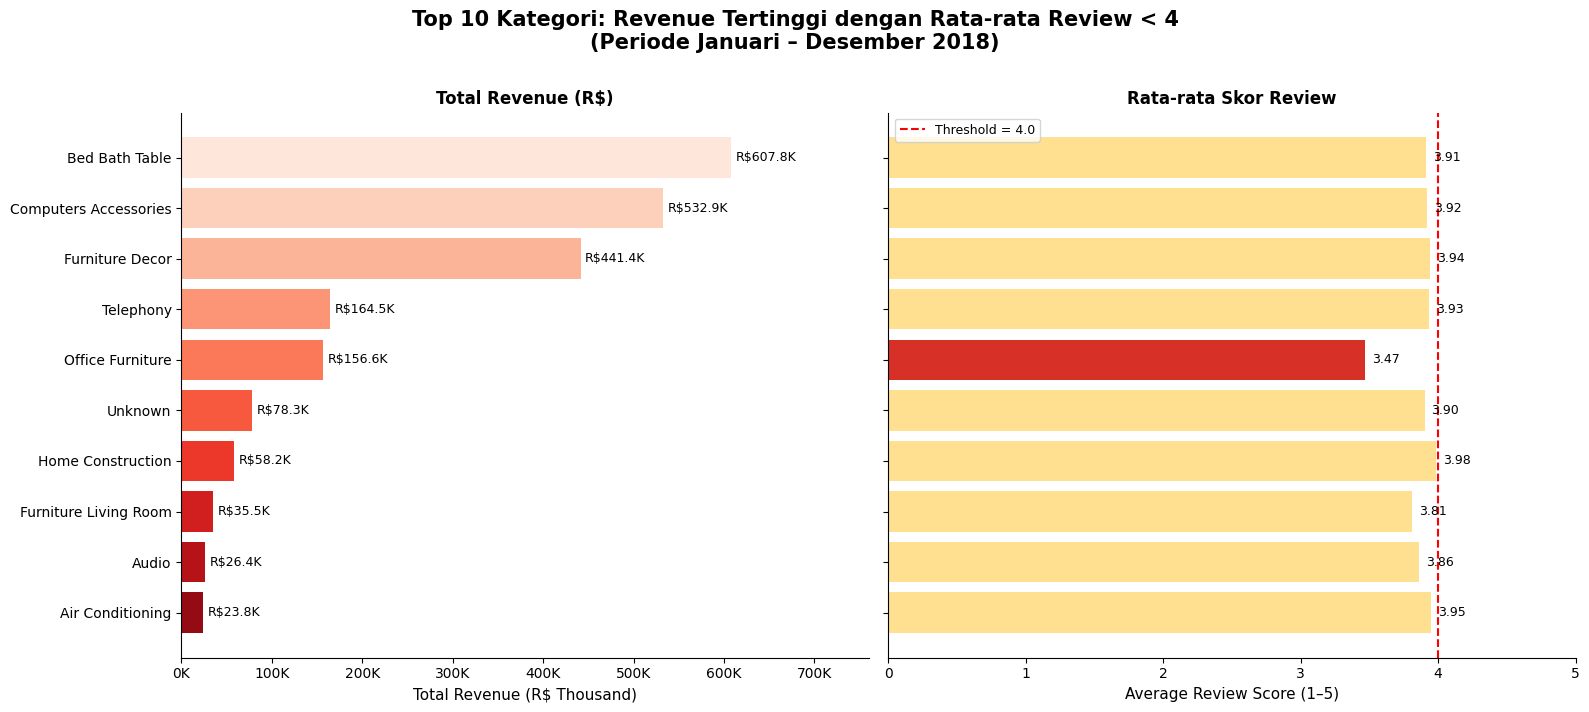

Visualisasi Q1 disimpan.


In [ ]:
top_product = 10
df_plot1 = category_problem_df.head(top_product).copy()
df_plot1['category_label'] = df_plot1['product_category_name_english'].str.replace('_', ' ').str.title()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    'Top 10 Kategori: Revenue Tertinggi dengan Rata-rata Review < 4\n(Periode Januari – Desember 2018)',
    fontsize=15, fontweight='bold', y=1.01
)

# Panel kiri: Total Revenue
colors_rev = sns.color_palette('Reds_r', top_product)
bars = axes[0].barh(
    df_plot1['category_label'][::-1],
    df_plot1['total_revenue'][::-1] / 1e3,
    color=colors_rev
)
axes[0].set_xlabel('Total Revenue (R$ Thousand)', fontsize=11)
axes[0].set_title('Total Revenue (R$)', fontsize=12, fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}K'))

for bar in bars:
    w = bar.get_width()
    axes[0].text(w + 5, bar.get_y() + bar.get_height()/2,
                 f'R${w:,.1f}K', va='center', ha='left', fontsize=9)

axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].set_xlim(0, df_plot1['total_revenue'].max() / 1e3 * 1.25)

# Panel kanan: Avg Review Score
score_colors = ['#d73027' if s < 3.5 else '#fc8d59' if s < 3.75 else '#fee090'
                for s in df_plot1['avg_review_score'][::-1]]
bars2 = axes[1].barh(
    df_plot1['category_label'][::-1],
    df_plot1['avg_review_score'][::-1],
    color=score_colors
)
axes[1].axvline(x=4, color='red', linestyle='--', linewidth=1.5, label='Threshold = 4.0')
axes[1].set_xlabel('Average Review Score (1–5)', fontsize=11)
axes[1].set_title('Rata-rata Skor Review', fontsize=12, fontweight='bold')
axes[1].set_xlim(0, 5)
axes[1].legend(fontsize=9)

for bar, val in zip(bars2, df_plot1['avg_review_score'][::-1]):
    axes[1].text(val + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', ha='left', fontsize=9)

axes[1].set_yticklabels([])
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('visualisasi_q1.png', bbox_inches='tight', dpi=150)
plt.show()
print('Visualisasi Q1 disimpan.')

### Pertanyaan 2: Berapa jumlah pelanggan yang termasuk dalam kategori “churn risk” berdasarkan lamanya waktu sejak transaksi terakhir melebihi 90 hari dan intensitas pembelian yang kurang dari 2 transaksi selama periode Januari – Desember 2018?

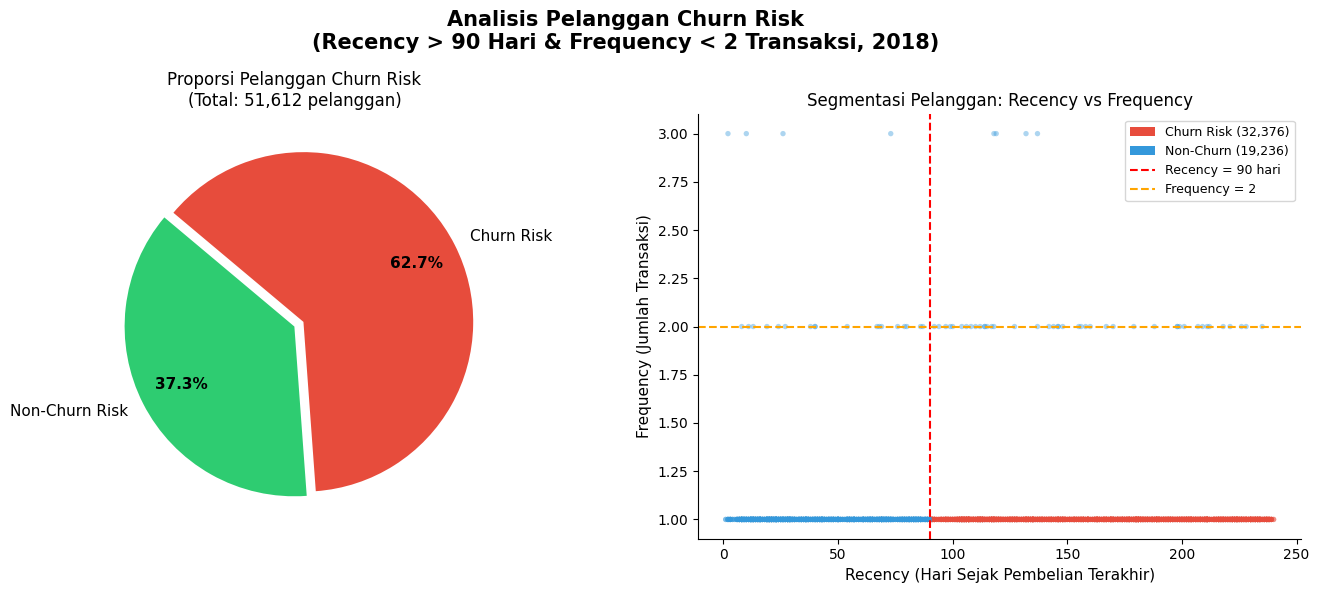

Visualisasi Q2 disimpan.


In [ ]:
# Visualisasi 2 Panel
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'Analisis Pelanggan Churn Risk\n(Recency > 90 Hari & Frequency < 2 Transaksi, 2018)',
    fontsize=15, fontweight='bold'
)

# Panel kiri: Pie chart proporsi churn vs non-churn
churn_counts = rfm_df_base['churn_risk'].value_counts()
labels = ['Non-Churn Risk', 'Churn Risk']
sizes  = [churn_counts.get(False, 0), churn_counts.get(True, 0)]
colors = ['#2ecc71', '#e74c3c']
explode = (0, 0.06)

wedges, texts, autotexts = axes[0].pie(
    sizes, labels=labels, colors=colors, autopct='%1.1f%%',
    startangle=140, explode=explode,
    textprops={'fontsize': 11}, pctdistance=0.75
)
for at in autotexts:
    at.set_fontweight('bold')
axes[0].set_title(f'Proporsi Pelanggan Churn Risk\n'
                  f'(Total: {sum(sizes):,} pelanggan)', fontsize=12)

# Panel kanan: Scatter recency vs frequency
sample = rfm_df_base.sample(min(3000, len(rfm_df_base)), random_state=42)
colors_s = ['#e74c3c' if c else '#3498db' for c in sample['churn_risk']]

axes[1].scatter(sample['recency_days'], sample['frequency'],
                c=colors_s, alpha=0.4, s=15, edgecolors='none')
axes[1].axvline(x=90, color='red', linestyle='--', linewidth=1.5, label='Recency = 90 hari')
axes[1].axhline(y=2,  color='orange', linestyle='--', linewidth=1.5, label='Frequency = 2')

# Patch
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label=f'Churn Risk ({churn_count:,})'),
    Patch(facecolor='#3498db', label=f'Non-Churn ({sum(sizes)-churn_count:,})'),
    plt.Line2D([0], [0], color='red', linestyle='--', label='Recency = 90 hari'),
    plt.Line2D([0], [0], color='orange', linestyle='--', label='Frequency = 2')
]
axes[1].legend(handles=legend_elements, fontsize=9, loc='upper right')
axes[1].set_xlabel('Recency (Hari Sejak Pembelian Terakhir)', fontsize=11)
axes[1].set_ylabel('Frequency (Jumlah Transaksi)', fontsize=11)
axes[1].set_title('Segmentasi Pelanggan: Recency vs Frequency', fontsize=12)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('visualisasi_q2.png', bbox_inches='tight', dpi=150)
plt.show()
print('Visualisasi Q2 disimpan.')

## Analisis Lanjutan (RFM Analysis)

Analisis ini dilakukan untuk mengelompokkan pelanggan berdasarkan tiga dimensi perilaku, yaitu:
- Recency (R): Jumlah hari sejak pelanggan melakukan transaksi terakhir.
- Frequency (F): Jumlah transaski yang dilakukan pelanggan.
- Monetary (M): Total pengeluaran pelanggan.

In [ ]:
# Tanggal pembelian terakhir di dataset 2018
ref_date = orders_df_2018['order_purchase_timestamp'].max()
print(f'Last date: {ref_date.date()}')

# Monetary
monetary_df = (
    master_df
    .groupby('customer_unique_id', as_index=False)
    .agg(monetary=('revenue', 'sum'))
)

# Gabungkan R, F dari rfm_df_base dan M dari monetary_df
rfm_df = rfm_df_base.merge(monetary_df, on='customer_unique_id', how='left')

print(rfm_df[['recency_days', 'frequency', 'monetary']].describe().round(2))

Last date: 2018-08-29
       recency_days  frequency  monetary
count      51612.00   51612.00  51612.00
mean         122.01       1.02    135.84
std           69.16       0.16    108.03
min            0.00       1.00      9.59
25%           62.00       1.00     62.65
50%          124.00       1.00    107.85
75%          182.00       1.00    177.49
max          240.00       7.00   4655.88


In [ ]:
# Recency score
rfm_df['r_score'] = pd.qcut(
    rfm_df['recency_days'], q=4, labels=[4, 3, 2, 1]
).astype(int)

# Frequency Score
rfm_df['f_score'] = pd.cut(
    rfm_df['frequency'],
    bins=[0, 1, 2, 3, rfm_df['frequency'].max()],
    labels=[1, 2, 3, 4]
).astype(int)

# Monetary Score
rfm_df['m_score'] = pd.qcut(
    rfm_df['monetary'], q=4, labels=[1, 2, 3, 4]
).astype(int)

rfm_df['rfm_score'] = rfm_df['r_score'] + rfm_df['f_score'] + rfm_df['m_score']

print('Distribusi R Score:'); print(rfm_df['r_score'].value_counts().sort_index())
print('\nDistribusi F Score:'); print(rfm_df['f_score'].value_counts().sort_index())
print('\nDistribusi M Score:'); print(rfm_df['m_score'].value_counts().sort_index())

Distribusi R Score:
r_score
1    12675
2    13015
3    12933
4    12989
Name: count, dtype: int64

Distribusi F Score:
f_score
1    50526
2     1020
3       54
4       12
Name: count, dtype: int64

Distribusi M Score:
m_score
1    12920
2    12890
3    12909
4    12893
Name: count, dtype: int64


In [ ]:
def segment_rfm(row):
    r, f, m = row['r_score'], row['f_score'], row['m_score']
    if r >= 3 and f >= 3:
        return 'Pelanggan Terbaik'
    elif r >= 3 and f == 2:
        return 'Pelanggan Setia'
    elif r >= 3 and f == 1 and m >= 3:
        return 'Pelanggan Potensial'
    elif r >= 3 and f == 1 and m < 3:
        return 'Pelanggan Baru'
    elif r == 2 and f >= 2:
        return 'Perlu Perhatian'
    elif r == 2 and f == 1:
        return 'Pelanggan Tidak Aktif'
    elif r == 1 and f >= 2:
        return 'Berisiko Churn'
    else:
        return 'Pelanggan Hilang'

rfm_df['segment'] = rfm_df.apply(segment_rfm, axis=1)

# Ringkasan per segmen
rfm_summary = (
    rfm_df.groupby('segment', as_index=False)
    .agg(
        jumlah_pelanggan=('customer_unique_id', 'count'),
        avg_recency=('recency_days', 'mean'),
        avg_frequency=('frequency', 'mean'),
        avg_monetary=('monetary', 'mean'),
        total_monetary=('monetary', 'sum')
    )
    .sort_values('jumlah_pelanggan', ascending=False)
    .reset_index(drop=True)
)

rfm_summary['avg_recency']   = rfm_summary['avg_recency'].round(1)
rfm_summary['avg_frequency'] = rfm_summary['avg_frequency'].round(2)
rfm_summary['avg_monetary']  = rfm_summary['avg_monetary'].round(2)

print('Ringkasan Segmentasi RFM:')
print(rfm_summary.to_string(index=False))

Ringkasan Segmentasi RFM:
              segment  jumlah_pelanggan  avg_recency  avg_frequency  avg_monetary  total_monetary
       Pelanggan Baru             12778         61.6           1.00         63.47      811061.645
Pelanggan Tidak Aktif             12765        153.7           1.00        135.04     1723824.790
  Pelanggan Potensial             12545         63.7           1.00        204.30     2562926.120
     Pelanggan Hilang             12438        211.1           1.00        129.24     1607434.345
      Pelanggan Setia               555         60.5           2.00        264.93      147035.450
      Perlu Perhatian               250        154.3           2.09        289.30       72323.785
       Berisiko Churn               237        204.5           2.02        256.13       60702.265
    Pelanggan Terbaik                44         65.4           3.30        581.84       25601.155


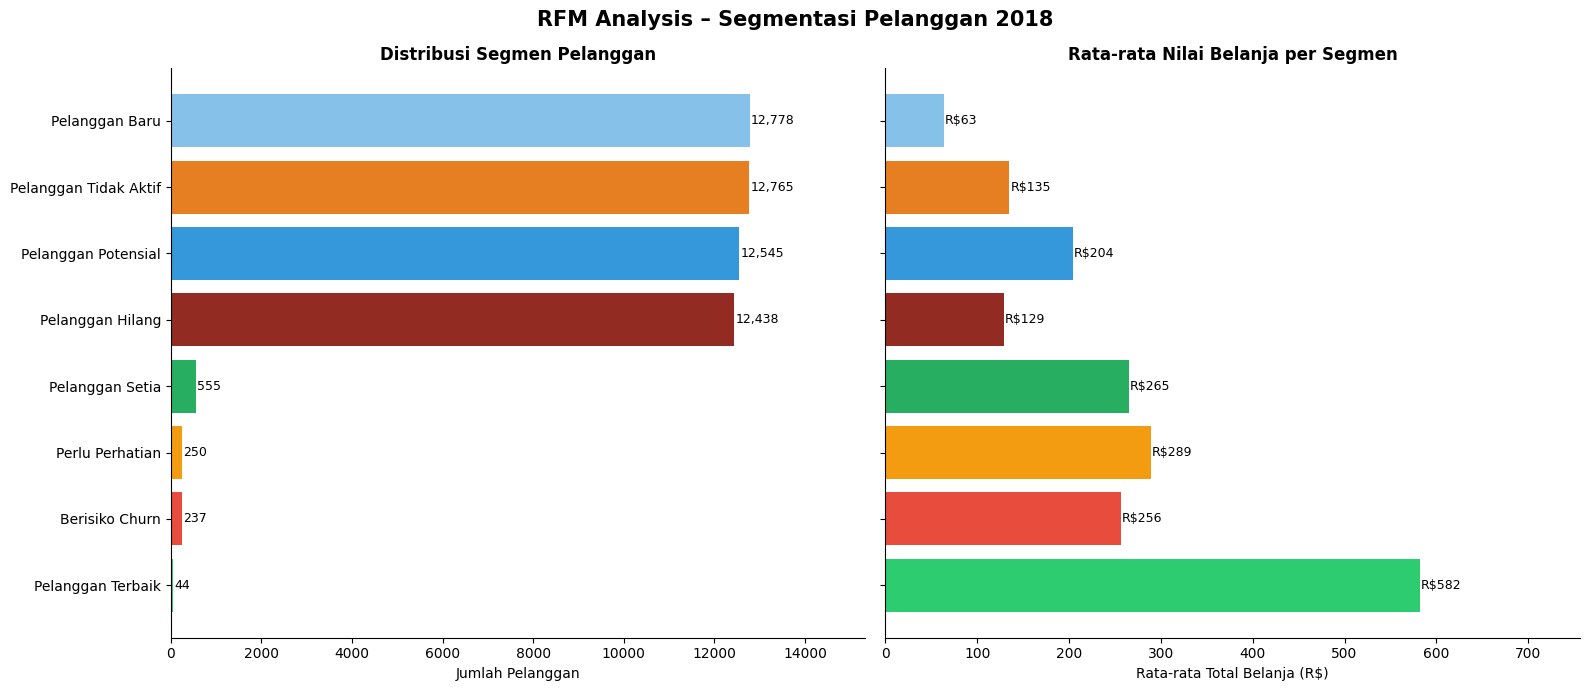

Visualisasi RFM disimpan.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('RFM Analysis – Segmentasi Pelanggan 2018',
             fontsize=15, fontweight='bold')

segment_order = rfm_summary.sort_values('jumlah_pelanggan')['segment'].tolist()
palette = {
    'Pelanggan Terbaik'     : '#2ecc71',
    'Pelanggan Setia'       : '#27ae60',
    'Pelanggan Potensial'   : '#3498db',
    'Pelanggan Baru'        : '#85c1e9',
    'Perlu Perhatian'       : '#f39c12',
    'Pelanggan Tidak Aktif' : '#e67e22',
    'Berisiko Churn'        : '#e74c3c',
    'Pelanggan Hilang'      : '#922b21'
}

# ── Panel kiri: Jumlah pelanggan per segmen ─────────────────
plot_data = rfm_summary.set_index('segment').loc[segment_order]
colors = [palette[s] for s in segment_order]

bars = axes[0].barh(segment_order, plot_data['jumlah_pelanggan'], color=colors)
for bar in bars:
    w = bar.get_width()
    axes[0].text(w + 30, bar.get_y() + bar.get_height() / 2,
                 f'{int(w):,}', va='center', fontsize=9)

axes[0].set_xlabel('Jumlah Pelanggan')
axes[0].set_title('Distribusi Segmen Pelanggan', fontweight='bold')
axes[0].set_xlim(0, plot_data['jumlah_pelanggan'].max() * 1.2)
axes[0].spines[['top', 'right']].set_visible(False)

# ── Panel kanan: Avg monetary per segmen ────────────────────
bars2 = axes[1].barh(segment_order, plot_data['avg_monetary'], color=colors)
for bar in bars2:
    w = bar.get_width()
    axes[1].text(w + 1, bar.get_y() + bar.get_height() / 2,
                 f'R${w:,.0f}', va='center', fontsize=9)

axes[1].set_xlabel('Rata-rata Total Belanja (R$)')
axes[1].set_title('Rata-rata Nilai Belanja per Segmen', fontweight='bold')
axes[1].set_xlim(0, plot_data['avg_monetary'].max() * 1.3)
axes[1].set_yticklabels([])
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('visualisasi_rfm.png', bbox_inches='tight', dpi=150)
plt.show()
print('Visualisasi RFM disimpan.')

**Insight:**
- `Pelanggan Baru` dan `Pelanggan Potensial` memilikii peluang untuk naik ke tingkat pelanggan setia. Perlu dilakukan campaign yang menarik minat mereka untuk terus melakukan transaksi.
- `Pelanggan Hilang` menjadi salah satu segmen yang tinggi karena kebanyakan pelanggan tidak bertransaksi kembali setelah pembelian pertama.
- `Pelanggan Terbaik` menjadi segmen yang berharga dengan distribusi yang paling rendah. Perlu dilakukan evaluasi untuk meningkatkan segmen ini.



## Conclusion & Recommendation

- **Conclusion Pertanyaan 1:**
  Selama tahun 2018 terdapat 5 kategori produk yang menghasilkan revenue tinggi dengan revenue besar sekitar ( >170.000), namun memiliki rata-rata skor review di bawah 4, yaitu:
  * Bed Bath Table (R$643653.48)
  * Computers Accessories (R$583989.37)
  * Furniture Decor (R$470024.38)
  * Telephony (R$210591.56)
  * Office Furniture (R$177904.36)
  Hal ini mengindikasikan bahwa pelanggan membeli produk tersebut dalam volume besar, namun tingkat kepuasan yang rendah terhadap kualitas produk atau layanan dapat berdampak dengan kurangnya aktivitas repeat purchase dan merusak reputasi marketplace.

- **Conclusion Pertanyaan 2:**
  Terdapat 32.376 pelanggan (62,7% dari total pelanggan 2018) yang masuk kategori churn risk (pelanggan yang tidak melakukan transaksi dalam 90 hari terakhir dan bertransaksi kurang dari 2 kali). Hal ini mengindikasikan bahwa marketplace memiliki permasalahan dalam loyalitas customer yang rendah.

**Rekomendasi Action Item:**
- Pertanyaan 1: Aksi yang dapat dilakukan untuk mengatasi tingkat kepuasan pelanggan yang rendah adalah dengan melakukan audit terhadap marketplace dan seller. Di tingkat marketplace yang berhubungan dengan kategori produk tersebut, dapat dilakukan survey kepada pelanggan terhadap layanan yang kurang maksimal. Marketplace dapat memberikan promo yang lebih menarik, layanan yang cepat tanggap, dan program garansi terhadap produk yang bermasalah. Hal ini untuk membangun kepercayaan pelanggan terhadap marketplace. Selain itu, dapat dilakukan audit di tingkat seller untuk menyediakan produk-produk yang berkualitas dari kategori produk tersebut. Apabila terdapat seller yang tidak mematuhi standar kualitas, maka marketplace berhak untuk mencabut izin jual seller tersebut. Hal ini dilakukan agar pelanggan nyaman dengan seller yang terpercaya.
- Pertanyaan 2: Untuk mengatasi permasalahan ini dapat dilakukan dengan menjaga hubungan pelanggan. Customer Relationship Management berperan penting untuk marketplace dan pelanggan agar tetap terhubung. Marketplace dapat melakukan campaign untuk menarik minat pelanggan dengan kategori churn risk. Campaign tersebut dapat berupa mengirim email atau notifikasi personalisasi yang berkaitan dengan produk terakhir kali mereka cari/beli. Selain itu, tim digital marketing juga dapat melakukan strategi iklan yang tertuju langsung terhadap pelanggan secara spesifik kategori churn risk tersebut.